In [1]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm

from pydub import AudioSegment
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
# creating the dataframe which has path to wav file and it's label

df = pd.read_csv('./data/data_prueba_preprocessed.csv')
df = df[['audio_path', 'label']]
print(df.shape)

(2096, 2)


In [3]:
# generate train test data
df_train, df_test, y_train, y_test = train_test_split(
    df, df['label'], 
    test_size=0.4, 
    random_state=42, 
    stratify=df['label']
)

In [4]:
# generate validation data
df_test, df_val, y_test, y_val = train_test_split(
    df_test, df_test['label'], 
    test_size=0.5, 
    random_state=42, 
    stratify=df_test['label']
)

In [5]:
X_train = df_train['audio_path']
X_test = df_test['audio_path']
X_val = df_val['audio_path']

In [6]:
#getting mfcc features for all the data points in test and train

def get_mfcc(path):
    """
    Extracts MFCC (Mel-frequency cepstral coefficients) features from an audio file.

    Parameters:
    path (str): The file path to the audio file.

    Returns:
    numpy.ndarray: A 2D array where each row corresponds to the MFCC features of a frame.
    """
    y, sr = librosa.load(path)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    return mfccs.T

In [7]:
def process_audio_files(X, y):
    """
    Processes a list of audio file paths to extract MFCC features and resize them.

    Args:
        X (pd.Series): A pandas Series containing paths to audio files.
        y (pd.Series): A pandas Series containing labels corresponding to the audio files.

    Returns:
        tuple: A tuple containing:
            - X_processed (np.ndarray): A numpy array of processed MFCC features with shape (num_files, 65, 40).
            - y_processed (np.ndarray): A numpy array of labels corresponding to the audio files.
    """
    temp = []
    label = []

    for i in tqdm(range(len(X))):
        audio_path = X.iloc[i]
        mfcc = get_mfcc(audio_path)
        mfcc = np.resize(mfcc, (65, 40,))
        temp.append(mfcc)
        label.append(y.iloc[i])

    X_processed = np.asarray(temp)
    y_processed = np.asarray(label)

    return X_processed, y_processed

In [8]:
%%time

X_train_processed, y_train = process_audio_files(X_train, y_train)
X_test_processed, y_test = process_audio_files(X_test, y_test)
X_val_processed, y_val = process_audio_files(X_val, y_val)

100%|██████████| 420/420 [01:09<00:00,  6.05it/s]

CPU times: user 12min 44s, sys: 15min 59s, total: 28min 44s
Wall time: 5min 39s


#### Modelling

In [9]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import keras.backend as K

tf.keras.backend.clear_session()

2024-10-01 12:33:05.400125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-01 12:33:05.418906: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-01 12:33:05.424430: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-01 12:33:05.439268: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


I0000 00:00:1727800393.794186  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727800393.851163  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727800393.851481  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [11]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
# Add attention layer to the deep learning network
class Attention(layers.Layer):
    """
    Custom Keras Layer implementing an Attention mechanism.

    Methods
    -------
    build(input_shape)
        Initializes the weights and biases for the attention mechanism.
    
    call(x)
        Applies the attention mechanism to the input tensor `x` and returns the context vector.

    Parameters
    ----------
    input_shape : tuple
        Shape of the input tensor.
    
    x : tensor
        Input tensor to which the attention mechanism is applied.

    Returns
    -------
    tensor
        Context vector obtained after applying the attention mechanism.
    """
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), 
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), 
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores. Pass them through tanh function
        e = tf.tanh(tf.matmul(x, self.W) + self.b)  # Cambiado K.dot por tf.matmul
        # Remove dimension of size 1
        e = tf.squeeze(e, axis=-1)  # Cambiado K.squeeze por tf.squeeze
        # Compute the weights
        alpha = tf.nn.softmax(e)  # Cambiado K.softmax por tf.nn.softmax
        # Reshape to tensorFlow format
        alpha = tf.expand_dims(alpha, axis=-1)  # Cambiado K.expand_dims por tf.expand_dims
        # Compute the context vector
        context = x * alpha
        context = tf.reduce_sum(context, axis=1)  # Cambiado K.sum por tf.reduce_sum
        return context

In [13]:
#Create model

#input
input = layers.Input(shape=(65,40), name='input_layer')

#cnn
x = layers.Conv1D(256, (3,), activation='relu')(input)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(128, (3,), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(64, (3,), activation='relu')(x)
x = layers.BatchNormalization()(x)
#lstm
x = layers.LSTM(256, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(128, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(64, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = Attention()(x)
#dense
x = layers.Dense(256,'relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128,'relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64,'relu')(x)
x = layers.Dropout(0.5)(x)

#output
output = layers.Dense(2, 'sigmoid', name='output_layer')(x)

model = Model(inputs=input, outputs=output)
model.summary()

I0000 00:00:1727800393.900738  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727800393.901132  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727800393.901389  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727800394.065151  567187 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 63, 256)        │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 59, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 59, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 59, 256)        │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 59, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 59, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 59, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,117 (3.01 MB)

 Trainable params: 788,221 (3.01 MB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_weights_mfcc.weights.h5',  
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_weights_only=True,  # guardar solo los pesos
    save_best_only=True,     # guardar solo el mejor modelo
)

# Callback para TensorBoard
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='logs',
    histogram_freq=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=5, 
    min_lr=0.00001)

# Callback para EarlyStopping
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min'
)

callbacks = [checkpoint_cb, tensorboard_cb, early_callback, reduce_lr]

In [ ]:
#model.load_weights('model_weights_mfcc-v3.weights.h5')

# Paso 3: Compilar el modelo (opcional)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
#compile
ls = tf.keras.losses.SparseCategoricalCrossentropy()
adam = tf.keras.optimizers.Adam()
model.compile(adam, ls, metrics=['accuracy'])

#fitting
history = model.fit(X_train_processed, y_train, 
                    validation_data = (X_val_processed, y_val),
                    callbacks=callbacks,
                    epochs = 100)

Epoch 1/100


2024-10-01 12:33:22.633747: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1727800402.726079  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.808669  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.809213  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.814691  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.815126  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.815620  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.816030  567293 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800402.817081  567293 gpu_t

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5281 - loss: 0.6972

W0000 00:00:1727800406.767989  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.768437  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.768915  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.769346  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.769726  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.770124  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.770501  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.770902  567291 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800406.771335  567291 gp


Epoch 1: val_loss improved from inf to 0.67465, saving model to model_weights_mfcc.weights.h5


W0000 00:00:1727800407.531656  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.532067  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.532484  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.532968  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.533414  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.533832  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.534222  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.534625  567294 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1727800407.535054  567294 gp

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.5291 - loss: 0.6971 - val_accuracy: 0.6000 - val_loss: 0.6746 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5525 - loss: 0.6907
Epoch 2: val_loss improved from 0.67465 to 0.67189, saving model to model_weights_mfcc.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5531 - loss: 0.6905 - val_accuracy: 0.6000 - val_loss: 0.6719 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6127 - loss: 0.6780
Epoch 3: val_loss improved from 0.67189 to 0.66952, saving model to model_weights_mfcc.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6124 - loss: 0.6780 - val_accuracy: 0.6000 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5636 - loss: 0.6871
Epoch 4: val_loss did not improve from 0.66952
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5644 - loss: 0.6868 - va

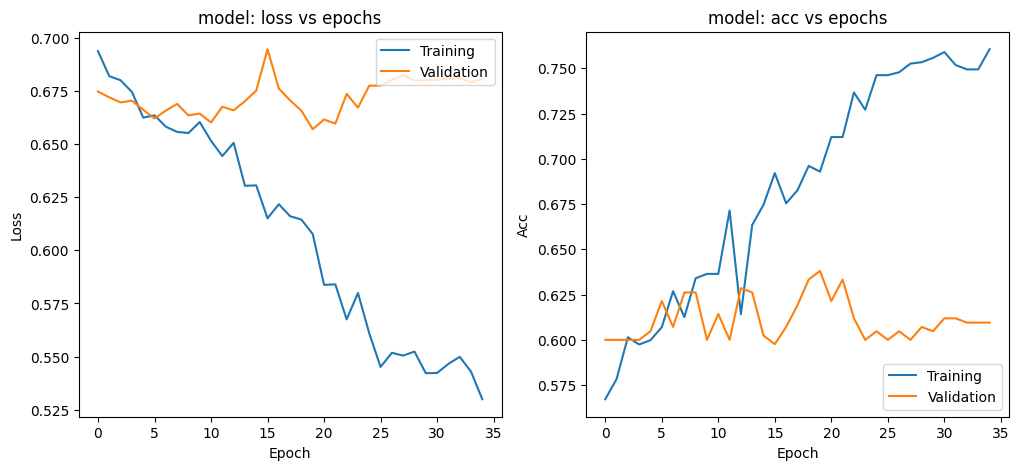

In [16]:
fig = plt.figure(figsize=(12, 5))
fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model: loss vs epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

#### Predictions

In [17]:
import os 
from multiprocessing import Pool

import pandas as pd
import numpy as np

from sklearn.metrics import f1_score
from scipy.sparse import lil_matrix

import tensorflow as tf 
from tqdm import tqdm

import librosa
from pydub import AudioSegment
from pydub.utils import make_chunks
from IPython.display import Audio

In [18]:
# ref: https://www.kaggle.com/code/arailly/multi-label-f-beta-score/notebook

# metrics function

def label_to_sm(labels, n_classes):
    """
    Converts a list of labels into a sparse matrix representation.

    Args:
        labels (list of int): A list of integer labels.
        n_classes (int): The number of classes.

    Returns:
        scipy.sparse.lil_matrix: A sparse matrix of shape (len(labels), n_classes) 
        where each row corresponds to a label and has a 1 in the column 
        corresponding to the label's class index.
    """
    sm = lil_matrix((len(labels), n_classes))
    for i, label in enumerate(labels):
        sm[i, label] = 1  #eg: sm[0, [2,3]] = 1
    return sm

###############################################

def get_f1_score(y_true, y_pred, average='weighted'):
    """
    Calculate the F1 score for the given true and predicted labels.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.
    average (str, optional): Type of averaging performed on the data. 
                             Default is 'weighted'. Other options include 
                             'micro', 'macro', 'samples', and 'binary'.

    Returns:
    float: The F1 score.
    """
    metric = f1_score(y_true=y_true, y_pred=y_pred, average=average)
    return metric

#################################################

def get_sm(y_true, y_pred):
    """
    Converts true and predicted labels to softmax representation.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        tuple: A tuple containing the softmax representations of the true and predicted labels.
    """
    y_true_sm = label_to_sm(labels=y_true, n_classes=2)
    y_pred_sm = label_to_sm(labels=y_pred, n_classes=2)
    return y_true_sm, y_pred_sm

In [54]:
def get_split(path):
    """
    Splits an audio file into 1.5-second chunks and exports each chunk as an MP3 file.

    Args:
        path (str): The file path to the input audio file in MP3 format.

    Returns:
        list: A list of file paths to the exported audio chunks.
    """
    myaudio = AudioSegment.from_file(path, "mp3")
    chunk_length_ms = 500  # pydub calcula en milisegundos
    chunks = make_chunks(myaudio, chunk_length_ms)  # Hacer trozos de 1.5 segundos

    # Crear la carpeta "chunks" si no existe
    if not os.path.exists("chunks"):
        os.makedirs("chunks")

    paths = []
    for i, chunk in enumerate(chunks):
        chunk_name = f"chunks/chunk{i}.mp3"  # Guardar en la carpeta "chunks"
        paths.append(chunk_name)
        chunk.export(chunk_name, format="mp3")

    return paths

##################################################

def get_mfcc(path):
    """
    Extracts Mel-frequency cepstral coefficients (MFCCs) from an audio file.

    Parameters:
    path (str): The file path to the audio file.

    Returns:
    numpy.ndarray: A 2D array of shape (65, 40) containing the MFCCs.
    """
    y, sr = librosa.load(path)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    mfccs = mfccs.T
    return np.resize(mfccs, (65, 40))

##################################################

def get_xqs(paths):
    """
    Extracts MFCC features from a list of file paths and returns them as a list.

    Args:
        paths (list of str): List of file paths to audio files.

    Returns:
        list: A list containing MFCC features for up to the first 6 audio files in the input list.
    """
    xqs = []
    for i in range(min(6, len(paths))): 
        t = get_mfcc(paths[i])
        xqs.append(t)
    return xqs

In [55]:
def get_probs(model, xqs):
    """
    Computes the prediction probabilities for a list of input sequences using the given model.

    Args:
        model (keras.Model): The trained model used for making predictions.
        xqs (list of numpy.ndarray): A list of input sequences, where each sequence is expected to be a 2D array of shape (65, 40).

    Returns:
        numpy.ndarray: An array of prediction probabilities for each input sequence.
    """
    probs = []
    for xq in xqs:
        xq = xq.reshape((1, 65, 40))
        p = model.predict(xq, verbose=0)
        probs.append(p)
    return np.array(probs)

def predict(model, xqs):
    """
    Predict the label for the given input data using the provided model.

    Args:
        model: The trained model used for making predictions.
        xqs: The input data for which predictions are to be made.

    Returns:
        int: The predicted label for the input data.
    """
    probs = get_probs(model, xqs)
    # Agregar
    s = np.max(probs, axis=0)
    label = np.argmax(s[0])
    return label

In [56]:
def test(model, df):
    """
    Tests the given model on the provided DataFrame and returns the true and predicted labels.

    Args:
        model: The machine learning model to be tested.
        df (pandas.DataFrame): DataFrame containing the test data. It must have columns 'label' and 'audio_path'.

    Returns:
        tuple: A tuple containing two lists:
            - y_true (list): The true labels from the DataFrame.
            - y_pred (list): The predicted labels from the model.
    """
    y_true = list(df['label'])
    y_pred = []
    for i in tqdm(range(len(df))):
        path = df['audio_path'].iloc[i]
        chunk_paths = get_split(path)
        xqs = get_xqs(chunk_paths)
        label = predict(model, xqs)
        y_pred.append(label)
    return y_true, y_pred

#########################################################

def evaluate(model, df):
    """
    Evaluates the given model using the provided dataframe.

    This function tests the model on the provided dataframe, calculates the F1 score
    with a weighted average, and returns the true labels, predicted labels, and the F1 score.

    Args:
        model: The machine learning model to be evaluated.
        df: A pandas DataFrame containing the data to test the model on.

    Returns:
        tuple: A tuple containing:
            - y_true (array-like): The true labels.
            - y_pred (array-like): The predicted labels by the model.
            - score (float): The weighted F1 score of the model's predictions.
    """
    y_true, y_pred = test(model, df)
    score = get_f1_score(y_true, y_pred, average='weighted')
    return y_true, y_pred, score

In [57]:
y_true, y_pred, score = evaluate(model, df_val)
score

100%|██████████| 420/420 [1:02:05<00:00,  8.87s/it]


0.6409559795081017

Text(0.5, 21.34715460257995, 'Predicted label')

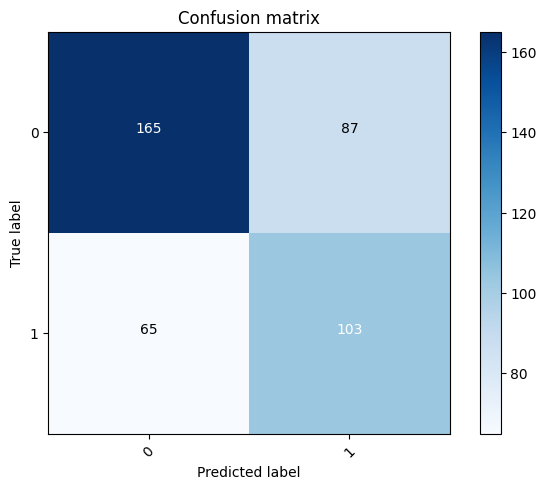

In [58]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import itertools

cm = confusion_matrix(y_val, y_pred) 

classes = 2

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(classes)
plt.xticks(tick_marks, range(classes), rotation=45)
plt.yticks(tick_marks, range(classes))

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > 100 else "black",
            )

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [59]:
roc_auc_score(y_val, y_pred)

0.6339285714285715

In [60]:
accuracy_score(y_val, y_pred)

0.638095238095238

In [61]:
from sklearn.metrics import classification_report

y_true, y_pred = get_sm(y_true, y_pred)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.65      0.68       252
           1       0.54      0.61      0.58       168

   micro avg       0.64      0.64      0.64       420
   macro avg       0.63      0.63      0.63       420
weighted avg       0.65      0.64      0.64       420
 samples avg       0.64      0.64      0.64       420

